# Train Model PM2.5, PM10, CO — LGBM + CatBoost

Alternatif model selain XGBoost:  
- **LightGBM** → MIRIP XGBoost, lebih cepat & hemat memori  
- **CatBoostRegressor** → Pengganti Prophet (Prophet sulit untuk data per menit dengan 14 hari data), robust terhadap overfitting  

Struktur identik dengan `train_pm25_pm10_co.ipynb`.

**Catatan:** Env vars `SUPABASE_URL` dan `SUPABASE_KEY` harus sudah di-set (atau ada di `.env`).

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from supabase import create_client, Client
import os
from datetime import datetime, timedelta
import joblib

SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

if not SUPABASE_URL or not SUPABASE_KEY:
    env_path = ".env"
    if os.path.exists(env_path):
        for line in open(env_path):
            if "=" in line and not line.startswith("#"):
                k, _, v = line.partition("=")
                os.environ[k.strip()] = v.strip().strip('"')
    SUPABASE_URL = os.getenv("SUPABASE_URL", "")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

SUPABASE_URL = SUPABASE_URL.replace("http://", "https://")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print(f"Connected to {SUPABASE_URL}")

Connected to https://knpwncirbhcytssrxcqx.supabase.co


### 1. Ambil Data

In [2]:
TABLE = "tb_konsentrasi_gas"
days_back = 14
since = (datetime.now() - timedelta(days=days_back)).isoformat()

all_data = []
offset = 0
while True:
    resp = supabase.table(TABLE) \
        .select("pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity,created_at") \
        .gte("created_at", since) \
        .order("created_at", desc=False) \
        .range(offset, offset + 999) \
        .execute()
    batch = resp.data
    if not batch:
        break
    all_data.extend(batch)
    offset += len(batch)

df = pd.DataFrame(all_data)
for col in ["pm25_ugm3","pm10_ugm3","co_ugm3","no2_ugm3","o3_ugm3","temperature","humidity"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_localize(None)
df = df.dropna(subset=["pm25_ugm3","pm10_ugm3","co_ugm3","temperature","humidity"])
df = df.set_index("created_at").sort_index()
df = df[~df.index.duplicated(keep="first")]
df.rename(columns={
    "pm25_ugm3": "pm25",
    "pm10_ugm3": "pm10",
    "co_ugm3": "co",
    "no2_ugm3": "no2",
    "o3_ugm3": "o3",
}, inplace=True)

print(f"Total: {len(df)} baris")
print(f"PM2.5: mean={df['pm25'].mean():.1f}, std={df['pm25'].std():.1f}")
print(f"PM10:  mean={df['pm10'].mean():.1f}, std={df['pm10'].std():.1f}")
print(f"CO:    mean={df['co'].mean():.1f}, std={df['co'].std():.1f}")

Total: 9805 baris
PM2.5: mean=15.3, std=3.0
PM10:  mean=16.9, std=4.2
CO:    mean=3078.4, std=480.9


### 2a. EDA & Uji Stasioneritas

Exploratory Data Analysis sebelum feature engineering:  
- Distribusi & time series  
- Uji stasioneritas (ADF)  
- ACF / PACF — tentukan lag optimal  
- Korelasi & cross-correlation antar polutan

In [3]:
print("=== RINGKASAN STATISTIK ===")
print(df[["pm25","pm10","co","no2","o3","temperature","humidity"]].describe().round(2))
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nRentang waktu: {df.index[0]} - {df.index[-1]}")
print(f"Total baris: {len(df)}")
print(f"Duplikat index: {df.index.duplicated().sum()}")

=== RINGKASAN STATISTIK ===
          pm25     pm10       co      no2       o3  temperature  humidity
count  9805.00  9805.00  9805.00  9805.00  9805.00      9805.00   9805.00
mean     15.33    16.93  3078.42     0.19    20.13        34.66     55.91
std       3.04     4.25   480.91     7.50     6.16         2.35      8.00
min       9.25     8.64   918.37     0.00     4.86        30.20     26.40
25%      13.30    14.45  2794.83     0.00    19.63        33.50     52.20
50%      14.54    16.07  3100.24     0.00    19.63        34.50     57.60
75%      16.47    18.40  3381.79     0.00    19.63        34.80     60.40
max      71.11   181.24  6486.81   309.59   128.00        47.30     98.00

=== MISSING VALUES ===
pm25           0
pm10           0
co             0
no2            0
o3             0
temperature    0
humidity       0
dtype: int64

Rentang waktu: 2026-05-31 16:29:36.259915 - 2026-06-13 02:12:36.016918
Total baris: 9805
Duplikat index: 0


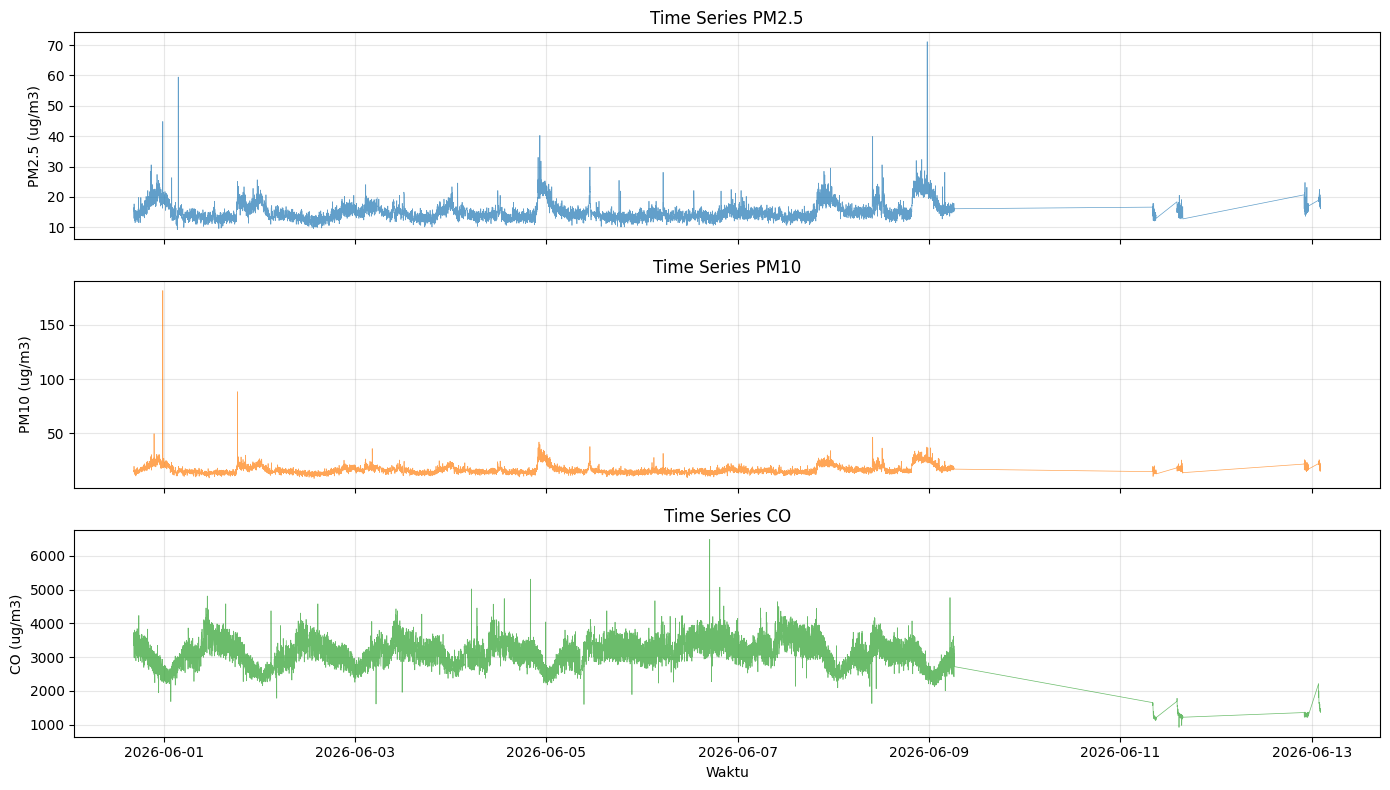

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["pm25"], color="tab:blue", alpha=0.7, linewidth=0.5)
axes[0].set_ylabel("PM2.5 (ug/m3)")
axes[0].set_title("Time Series PM2.5")
axes[0].grid(alpha=0.3)
axes[1].plot(df.index, df["pm10"], color="tab:orange", alpha=0.7, linewidth=0.5)
axes[1].set_ylabel("PM10 (ug/m3)")
axes[1].set_title("Time Series PM10")
axes[1].grid(alpha=0.3)
axes[2].plot(df.index, df["co"], color="tab:green", alpha=0.7, linewidth=0.5)
axes[2].set_ylabel("CO (ug/m3)")
axes[2].set_title("Time Series CO")
axes[2].grid(alpha=0.3)
plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

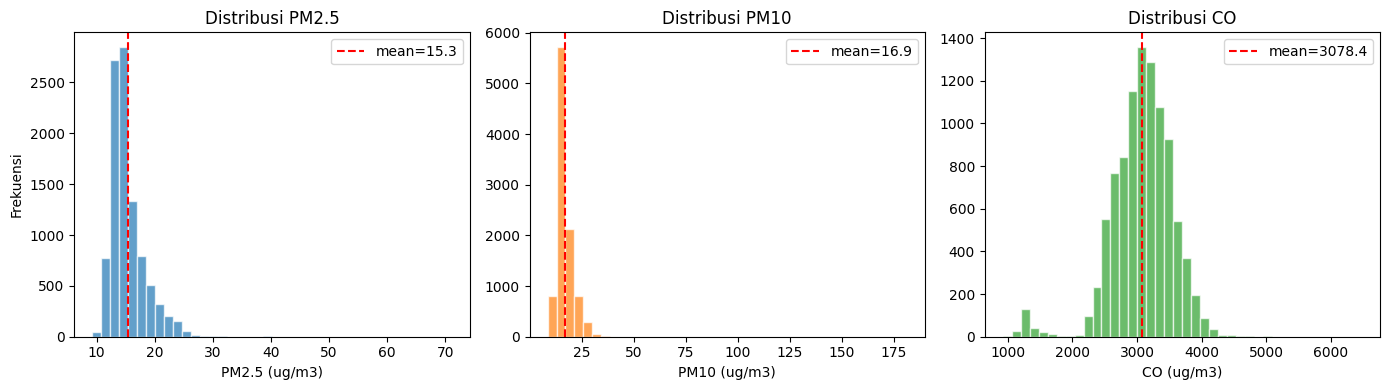

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df["pm25"], bins=40, color="tab:blue", edgecolor="white", alpha=0.7)
axes[0].set_xlabel("PM2.5 (ug/m3)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi PM2.5")
axes[0].axvline(df["pm25"].mean(), color="red", ls="--", label=f"mean={df['pm25'].mean():.1f}")
axes[0].legend()
axes[1].hist(df["pm10"], bins=40, color="tab:orange", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("PM10 (ug/m3)")
axes[1].set_title("Distribusi PM10")
axes[1].axvline(df["pm10"].mean(), color="red", ls="--", label=f"mean={df['pm10'].mean():.1f}")
axes[1].legend()
axes[2].hist(df["co"], bins=40, color="tab:green", edgecolor="white", alpha=0.7)
axes[2].set_xlabel("CO (ug/m3)")
axes[2].set_title("Distribusi CO")
axes[2].axvline(df["co"].mean(), color="red", ls="--", label=f"mean={df['co'].mean():.1f}")
axes[2].legend()
plt.tight_layout()
plt.show()

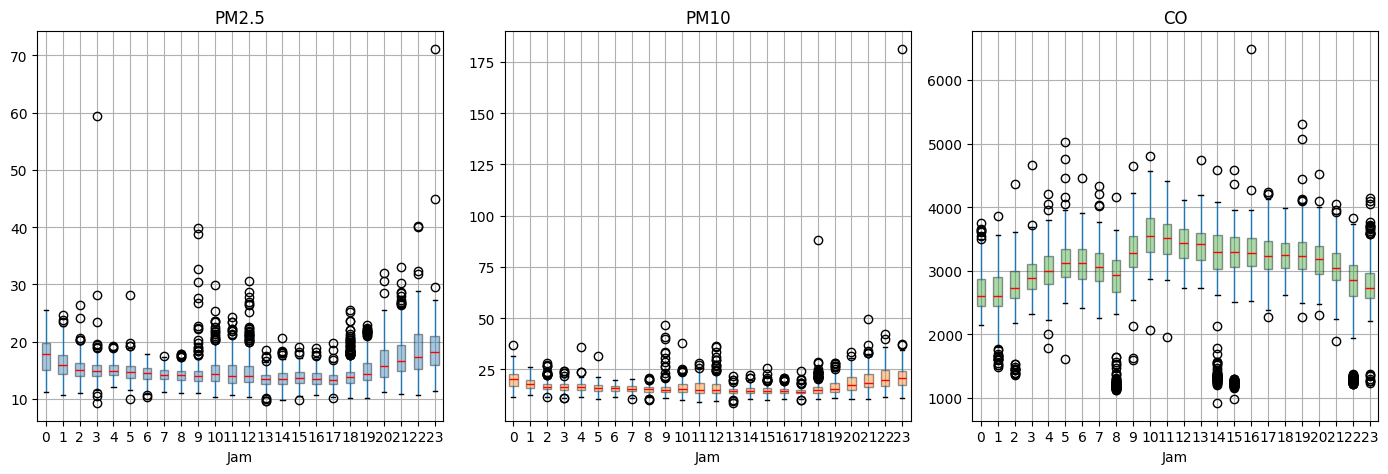

In [6]:
df_box = df.copy()
df_box["hour"] = df_box.index.hour
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, color, title in zip(axes, ["pm25","pm10","co"], ["tab:blue","tab:orange","tab:green"], ["PM2.5","PM10","CO"]):
    df_box.boxplot(column=col, by="hour", ax=ax, grid=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.4), medianprops=dict(color="red"))
    ax.set_title(title)
    ax.set_xlabel("Jam")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller
print("=== UJI STASIONERITAS (ADF) ===\n")
for col in ["pm25", "pm10", "co"]:
    stat, pval, usedlag, nobs, crit, icbest = adfuller(df[col].dropna())
    msg = "STASIONER" if pval < 0.05 else "TIDAK STASIONER"
    print(f"{col.upper():6s} | ADF={stat:.4f} | p-value={pval:.6f} | {msg}")

=== UJI STASIONERITAS (ADF) ===

PM25   | ADF=-4.7273 | p-value=0.000075 | STASIONER
PM10   | ADF=-4.9736 | p-value=0.000025 | STASIONER
CO     | ADF=-2.6464 | p-value=0.083783 | TIDAK STASIONER


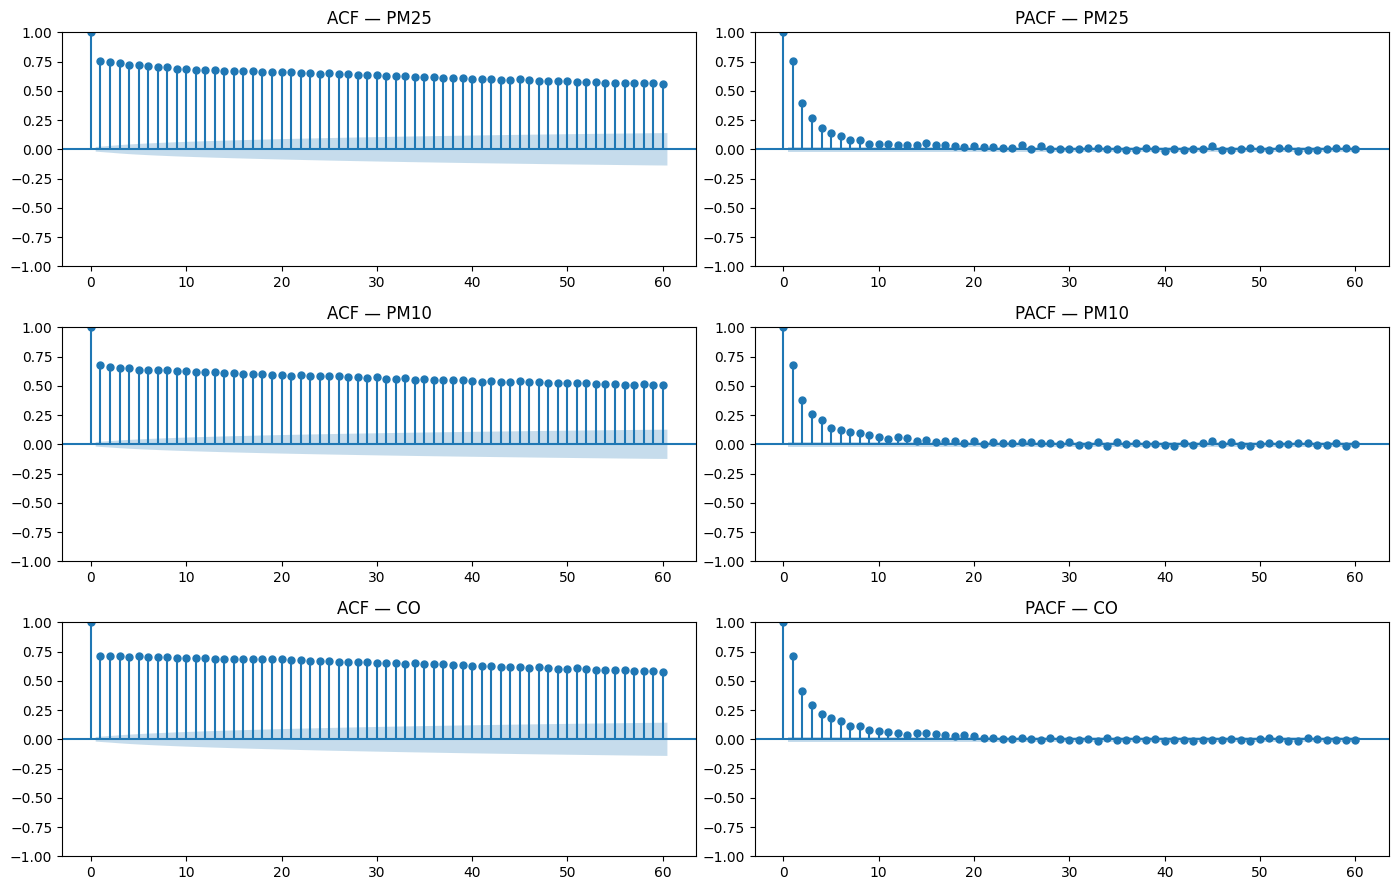

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
lags = 60
for i, col in enumerate(["pm25", "pm10", "co"]):
    plot_acf(df[col].dropna(), lags=lags, ax=axes[i,0])
    axes[i,0].set_title(f"ACF — {col.upper()}")
    plot_pacf(df[col].dropna(), lags=lags, ax=axes[i,1], method="ywm")
    axes[i,1].set_title(f"PACF — {col.upper()}")
plt.tight_layout()
plt.show()

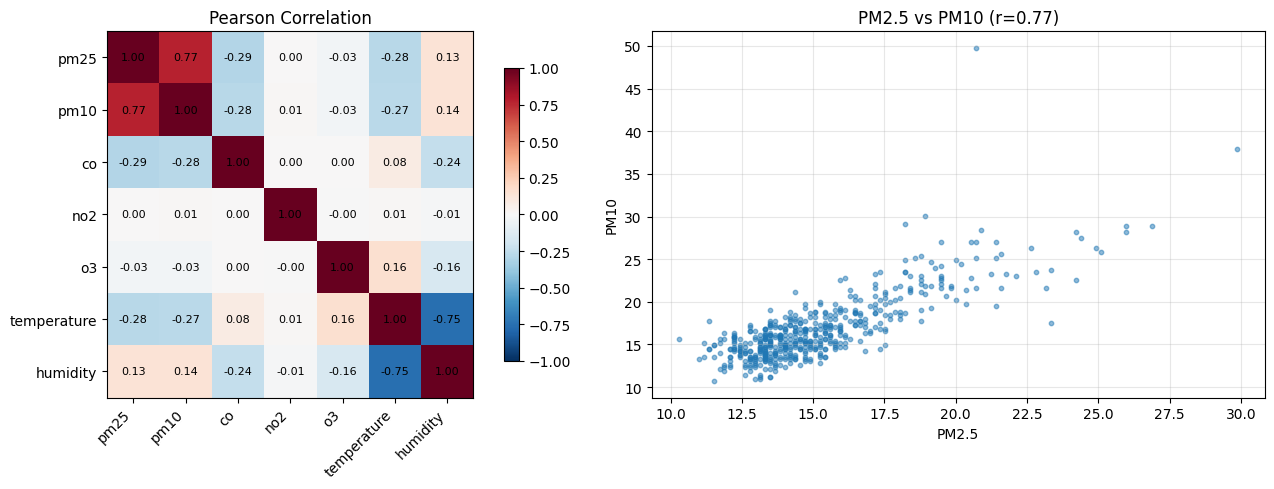

In [9]:
corr_cols = ["pm25","pm10","co","no2","o3","temperature","humidity"]
corr = df[corr_cols].corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_cols)))
axes[0].set_yticks(range(len(corr_cols)))
axes[0].set_xticklabels(corr_cols, rotation=45, ha="right")
axes[0].set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_title("Pearson Correlation")
plt.colorbar(im, ax=axes[0], shrink=0.8)
scatter = df[corr_cols].sample(min(500, len(df)))
axes[1].scatter(scatter["pm25"], scatter["pm10"], s=10, alpha=0.5, c="tab:blue")
axes[1].set_xlabel("PM2.5")
axes[1].set_ylabel("PM10")
axes[1].set_title(f"PM2.5 vs PM10 (r={corr.loc['pm25','pm10']:.2f})")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

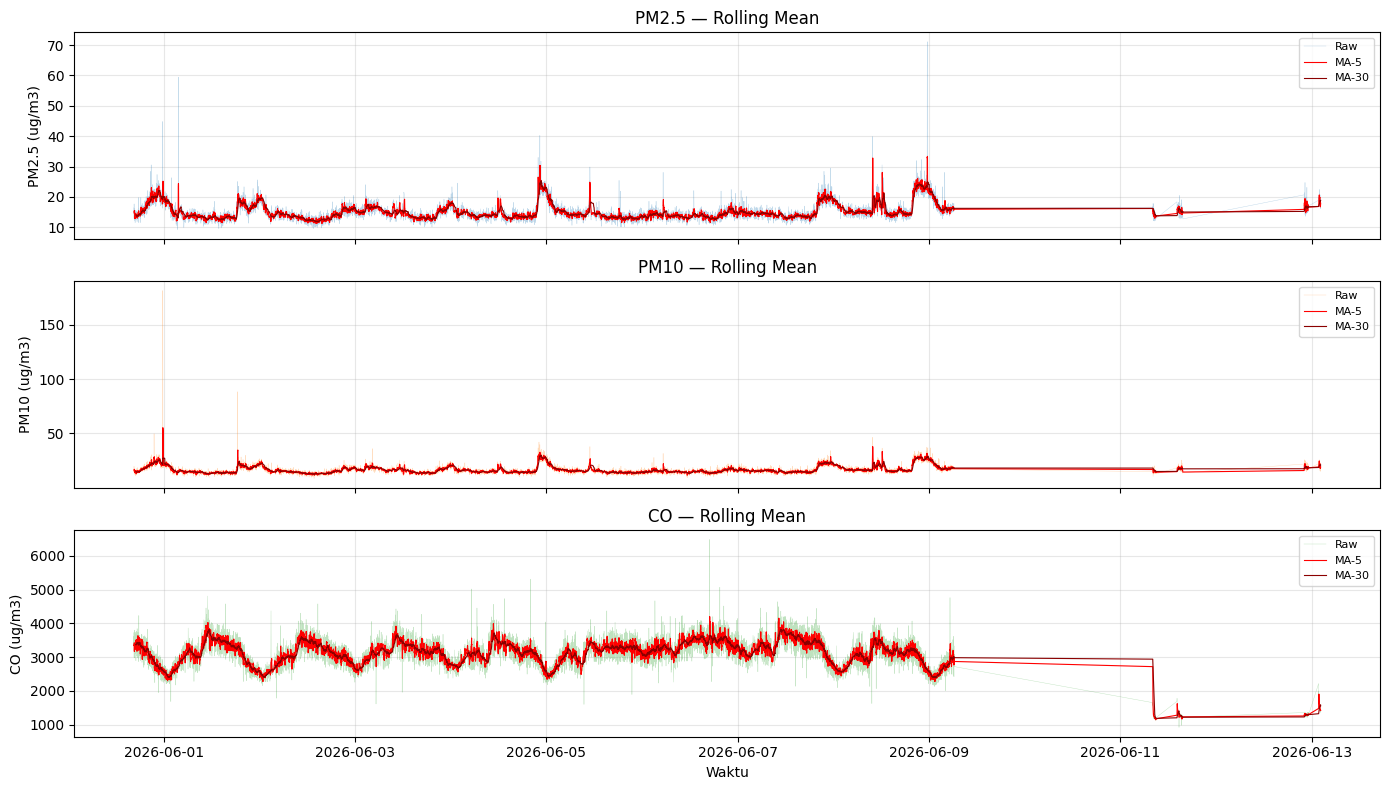

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, col, color, title in zip(axes, ["pm25","pm10","co"], ["tab:blue","tab:orange","tab:green"], ["PM2.5","PM10","CO"]):
    vals = df[col].dropna()
    roll_mean_5 = vals.rolling(5).mean()
    roll_mean_30 = vals.rolling(30).mean()
    ax.plot(vals.index, vals, alpha=0.3, linewidth=0.3, color=color, label="Raw")
    ax.plot(vals.index, roll_mean_5, linewidth=0.8, color="red", label="MA-5")
    ax.plot(vals.index, roll_mean_30, linewidth=0.8, color="darkred", label="MA-30")
    ax.set_ylabel(f"{title} (ug/m3)")
    ax.set_title(f"{title} — Rolling Mean")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

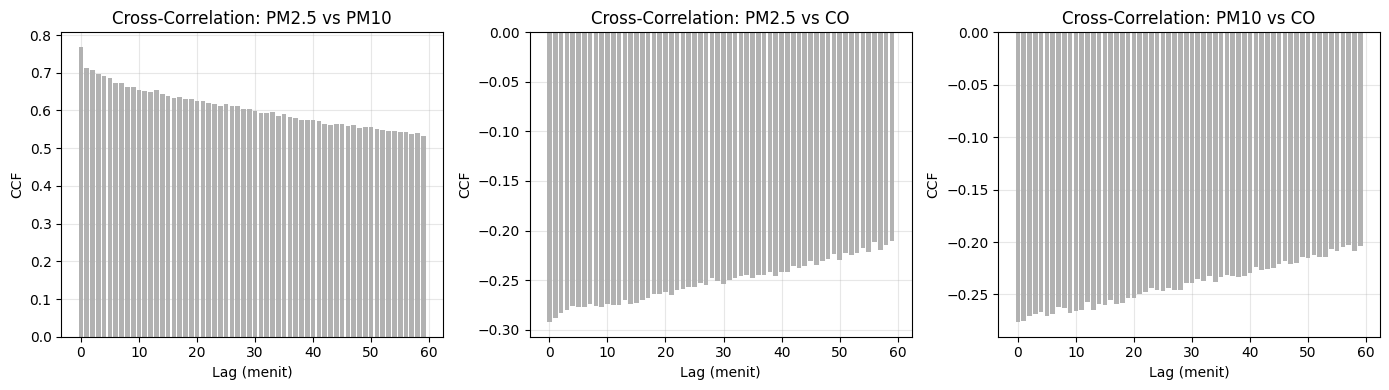

In [11]:
from statsmodels.tsa.stattools import ccf
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (a, b, label) in zip(axes, [
    ("pm25","pm10","PM2.5 vs PM10"),
    ("pm25","co","PM2.5 vs CO"),
    ("pm10","co","PM10 vs CO"),
]):
    vals_a = df[a].dropna().values
    vals_b = df[b].dropna().values
    min_len = min(len(vals_a), len(vals_b))
    cc = ccf(vals_a[:min_len], vals_b[:min_len], adjusted=False)[:60]
    ax.bar(range(len(cc)), cc, width=0.8, color="gray", alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Cross-Correlation: {label}")
    ax.set_xlabel("Lag (menit)")
    ax.set_ylabel("CCF")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Feature Engineering (identik)

In [12]:
RAW_COLS = ["pm25", "pm10", "co", "no2", "temperature", "humidity"]

feat = df.copy()

for col in RAW_COLS:
    if col not in feat.columns:
        continue
    feat[f"{col}_lag_1min"] = feat[col].shift(1)
    feat[f"{col}_lag_5min"] = feat[col].shift(5)
    feat[f"{col}_lag_15min"] = feat[col].shift(15)
    feat[f"{col}_lag_60min"] = feat[col].shift(60)
    feat[f"{col}_rolling_mean_5min"] = feat[col].rolling(window=5).mean()
    feat[f"{col}_rolling_std_5min"] = feat[col].rolling(window=5).std()
    feat[f"{col}_rolling_mean_15min"] = feat[col].rolling(window=15).mean()

feat["minute"] = feat.index.minute
feat["hour"] = feat.index.hour
feat["dayofweek"] = feat.index.dayofweek

print(f"Fitur: {len(feat.columns)} kolom")

Fitur: 52 kolom


### 3. Train LGBM — PM2.5, PM10, CO

In [13]:
LGBM_TARGETS = {
    "pm25": {"model": lgb.LGBMRegressor, "pkl": "lgbm_pm25.pkl"},
    "pm10": {"model": lgb.LGBMRegressor, "pkl": "lgbm_pm10.pkl"},
    "co":   {"model": lgb.LGBMRegressor, "pkl": "lgbm_co.pkl"},
}

LGBM_PARAMS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbosity": -1,
}

FEATURE_COLS = [c for c in feat.columns if c not in ["pm25", "pm10", "co", "no2", "o3"]]
print(f"Feature cols: {len(FEATURE_COLS)}")

lgbm_results = {}

for target_name, config in LGBM_TARGETS.items():
    print(f"\n{'='*60}")
    print(f"Training LightGBM untuk {target_name.upper()}")
    print(f"{'='*60}")

    y = feat[target_name]
    X = feat[FEATURE_COLS].copy()

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = config["model"](**LGBM_PARAMS)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    joblib.dump(model, config["pkl"])

    lgbm_results[target_name] = {
        "pkl": config["pkl"],
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        "r2": round(r2, 4),
        "train": len(X_train),
        "test": len(X_test),
    }

    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f} ({r2*100:.2f}%)")
    print(f"  PKL  : {config['pkl']}")

print(f"\n{'='*60}")
print("RINGKASAN LGBM")
print(f"{'='*60}")
for name, r in lgbm_results.items():
    print(f"  {name.upper():6s} | R2={r['r2']:.4f} ({r['r2']*100:.1f}%) | MAE={r['mae']:.4f} | {r['pkl']}")

Feature cols: 47

Training LightGBM untuk PM25
  MAE  : 1.0684
  RMSE : 1.8647
  R2   : 0.7403 (74.03%)
  PKL  : lgbm_pm25.pkl

Training LightGBM untuk PM10
  MAE  : 1.4335
  RMSE : 2.0292
  R2   : 0.7905 (79.05%)
  PKL  : lgbm_pm10.pkl

Training LightGBM untuk CO
  MAE  : 279.2288
  RMSE : 444.5498
  R2   : 0.5116 (51.16%)
  PKL  : lgbm_co.pkl

RINGKASAN LGBM
  PM25   | R2=0.7403 (74.0%) | MAE=1.0684 | lgbm_pm25.pkl
  PM10   | R2=0.7905 (79.0%) | MAE=1.4335 | lgbm_pm10.pkl
  CO     | R2=0.5116 (51.2%) | MAE=279.2288 | lgbm_co.pkl


### 4. Train CatBoost — PM2.5, PM10, CO

> CatBoost dipilih sebagai pengganti Prophet karena:  
> - Prophet membutuhkan format `ds`/`y` dan kurang optimal untuk data per-menit (14 hari)  
> - CatBoost sama-sama gradient boosting, handle overfitting lebih baik, dan terintegrasi langsung dengan feature engineering yang sama

In [14]:
CAT_TARGETS = {
    "pm25": {"model": CatBoostRegressor, "pkl": "catboost_pm25.pkl"},
    "pm10": {"model": CatBoostRegressor, "pkl": "catboost_pm10.pkl"},
    "co":   {"model": CatBoostRegressor, "pkl": "catboost_co.pkl"},
}

CB_PARAMS = {
    "iterations": 300,
    "depth": 6,
    "learning_rate": 0.05,
    "random_seed": 42,
    "verbose": False,
    "loss_function": "RMSE",
}

cat_results = {}

for target_name, config in CAT_TARGETS.items():
    print(f"\n{'='*60}")
    print(f"Training CatBoost untuk {target_name.upper()}")
    print(f"{'='*60}")

    y = feat[target_name]
    X = feat[FEATURE_COLS].copy()

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = config["model"](**CB_PARAMS)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    joblib.dump(model, config["pkl"])

    cat_results[target_name] = {
        "pkl": config["pkl"],
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        "r2": round(r2, 4),
        "train": len(X_train),
        "test": len(X_test),
    }

    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f} ({r2*100:.2f}%)")
    print(f"  PKL  : {config['pkl']}")

print(f"\n{'='*60}")
print("RINGKASAN CATBOOST")
print(f"{'='*60}")
for name, r in cat_results.items():
    print(f"  {name.upper():6s} | R2={r['r2']:.4f} ({r['r2']*100:.1f}%) | MAE={r['mae']:.4f} | {r['pkl']}")


Training CatBoost untuk PM25
  MAE  : 1.0667
  RMSE : 1.8895
  R2   : 0.7334 (73.34%)
  PKL  : catboost_pm25.pkl

Training CatBoost untuk PM10
  MAE  : 1.7026
  RMSE : 2.9673
  R2   : 0.5521 (55.21%)
  PKL  : catboost_pm10.pkl

Training CatBoost untuk CO
  MAE  : 286.1854
  RMSE : 463.8249
  R2   : 0.4684 (46.84%)
  PKL  : catboost_co.pkl

RINGKASAN CATBOOST
  PM25   | R2=0.7334 (73.3%) | MAE=1.0667 | catboost_pm25.pkl
  PM10   | R2=0.5521 (55.2%) | MAE=1.7026 | catboost_pm10.pkl
  CO     | R2=0.4684 (46.8%) | MAE=286.1854 | catboost_co.pkl


### 5. Perbandingan XGBoost vs LGBM vs CatBoost

In [15]:
print(f"{'='*80}")
print(f"{'Target':<8} {'Model':<12} {'R2':<10} {'MAE':<10} {'RMSE':<10} {'PKL':<25}")
print(f"{'='*80}")

for target in ["pm25", "pm10", "co"]:
    if target in lgbm_results:
        r = lgbm_results[target]
        print(f"{target.upper():<8} {'LightGBM':<12} {r['r2']:<10.4f} {r['mae']:<10.4f} {r['rmse']:<10.4f} {r['pkl']:<25}")
    if target in cat_results:
        r = cat_results[target]
        print(f"{target.upper():<8} {'CatBoost':<12} {r['r2']:<10.4f} {r['mae']:<10.4f} {r['rmse']:<10.4f} {r['pkl']:<25}")
    print()

print("\nCatatan: Hasil XGBoost (xgb_pm25/10/co_v2.pkl) ada di notebook train_pm25_pm10_co.ipynb")

Target   Model        R2         MAE        RMSE       PKL                      
PM25     LightGBM     0.7403     1.0684     1.8647     lgbm_pm25.pkl            
PM25     CatBoost     0.7334     1.0667     1.8895     catboost_pm25.pkl        

PM10     LightGBM     0.7905     1.4335     2.0292     lgbm_pm10.pkl            
PM10     CatBoost     0.5521     1.7026     2.9673     catboost_pm10.pkl        

CO       LightGBM     0.5116     279.2288   444.5498   lgbm_co.pkl              
CO       CatBoost     0.4684     286.1854   463.8249   catboost_co.pkl          


Catatan: Hasil XGBoost (xgb_pm25/10/co_v2.pkl) ada di notebook train_pm25_pm10_co.ipynb


### 6. Quick Test Prediksi

In [16]:
feat_test = feat.dropna().iloc[[-1]]
X_row = feat_test[FEATURE_COLS]

print("Nilai aktual saat ini:")
print(f"  PM2.5 : {feat_test['pm25'].values[0]:.1f} ug/m3")
print(f"  PM10  : {feat_test['pm10'].values[0]:.1f} ug/m3")
print(f"  CO    : {feat_test['co'].values[0]:.1f} ug/m3")

print("\nPrediksi 1 menit ke depan — LGBM:")
for target_name, config in LGBM_TARGETS.items():
    model = joblib.load(config["pkl"])
    pred = float(model.predict(X_row.values)[0])
    actual = feat_test[target_name].values[0]
    print(f"  {target_name.upper():6s} : {pred:.1f} (actual: {actual:.1f})")

print("\nPrediksi 1 menit ke depan — CatBoost:")
for target_name, config in CAT_TARGETS.items():
    model = joblib.load(config["pkl"])
    pred = float(model.predict(X_row.values)[0])
    actual = feat_test[target_name].values[0]
    print(f"  {target_name.upper():6s} : {pred:.1f} (actual: {actual:.1f})")

Nilai aktual saat ini:
  PM2.5 : 19.3 ug/m3
  PM10  : 19.3 ug/m3
  CO    : 1354.5 ug/m3

Prediksi 1 menit ke depan — LGBM:
  PM25   : 17.8 (actual: 19.3)
  PM10   : 22.3 (actual: 19.3)
  CO     : 2502.5 (actual: 1354.5)

Prediksi 1 menit ke depan — CatBoost:
  PM25   : 18.1 (actual: 19.3)
  PM10   : 19.0 (actual: 19.3)
  CO     : 2508.6 (actual: 1354.5)


c:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
